# E. 배송 성능 & 만족도 연계

배송 소요일·예상 대비 지연 여부를 계산하고, 리뷰 점수와의 관계를 살펴봅니다.

**사용 데이터**: `data/` (00 실행 후).

## 1. 데이터 로드 및 배송 지표 계산

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path.cwd() / "data"
for _ in [Path.cwd() / "data", Path.cwd().parent / "예측 대시보드 용 프로젝트" / "data"]:
    if (_ / "orders_delivered.csv").exists():
        DATA_DIR = _
        break
if not (DATA_DIR / "orders_delivered.csv").exists():
    import kagglehub
    _path = Path(kagglehub.dataset_download("olistbr/brazilian-ecommerce"))
    orders = pd.read_csv(_path / "olist_orders_dataset.csv")
    orders = orders[orders["order_status"] == "delivered"].copy()
    order_reviews = pd.read_csv(_path / "olist_order_reviews_dataset.csv")
    print("(data/ 없음 → kagglehub에서 로드)")
else:
    orders = pd.read_csv(DATA_DIR / "orders_delivered.csv")
    order_reviews = pd.read_csv(DATA_DIR / "order_reviews.csv")

for c in ["order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date", "order_purchase_timestamp"]:
    if c in orders.columns:
        orders[c] = pd.to_datetime(orders[c], errors="coerce")
orders["order_week_start"] = orders["order_purchase_timestamp"].dt.to_period("W-MON").dt.start_time

# 배송 소요일 (승인 ~ 고객 도착)
orders["delivery_days"] = (orders["order_delivered_customer_date"] - orders["order_approved_at"]).dt.total_seconds() / (24 * 3600)
# 예상 대비 지연 (도착일 > 예상도착일 이면 지연)
orders["is_delayed"] = orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"]

# 리뷰와 조인 (주문당 1리뷰)
rev = order_reviews.groupby("order_id").agg(review_score=("review_score", "first")).reset_index()
orders_rev = orders.merge(rev, on="order_id", how="inner")
orders_rev = orders_rev.dropna(subset=["delivery_days"])
print("배송+리뷰 행:", len(orders_rev))
print("평균 배송 소요일:", orders_rev["delivery_days"].mean().round(1))
print("지연 비율(%):", orders_rev["is_delayed"].mean() * 100)

배송+리뷰 행: 95810
평균 배송 소요일: 12.1
지연 비율(%): 7.996033816929339


## 2. 배송 소요일 구간별 평균 리뷰 점수

In [2]:
orders_rev["delivery_bin"] = pd.cut(orders_rev["delivery_days"], bins=[0, 7, 14, 21, 60, 500], labels=["7일 이내", "8~14일", "15~21일", "22~60일", "60일+"])
by_delivery = orders_rev.groupby("delivery_bin", observed=True).agg(
    주문수=("order_id", "count"),
    평균_리뷰점수=("review_score", "mean"),
).round(2)
print(by_delivery)

                주문수  평균_리뷰점수
delivery_bin                
7일 이내         29021    4.410
8~14일         38780    4.300
15~21일        16392    4.130
22~60일        11275    3.090
60일+            283    2.150


### 2.1 주별 배송 지표 (대시보드용)

**order_week_start** 기준 주별 평균 배송 소요일·지연 비율·평균 리뷰 점수입니다.

In [ ]:
by_week = orders_rev.groupby("order_week_start").agg(
    주문수=("order_id", "count"),
    평균_배송소요일=("delivery_days", "mean"),
    지연비율=("is_delayed", "mean"),
    평균_리뷰점수=("review_score", "mean"),
).round(2).reset_index()
print(by_week.head(15))

## 3. 지연 여부별 만족도

In [3]:
by_delay = orders_rev.groupby("is_delayed").agg(
    주문수=("order_id", "count"),
    평균_리뷰점수=("review_score", "mean"),
    저평점_비율=("review_score", lambda x: (x <= 2).mean() * 100),
).round(2)
by_delay.index = ["정시 배송", "지연"]
print(by_delay)

         주문수  평균_리뷰점수  저평점_비율
정시 배송  88149    4.290   9.220
지연      7661    2.570  54.070


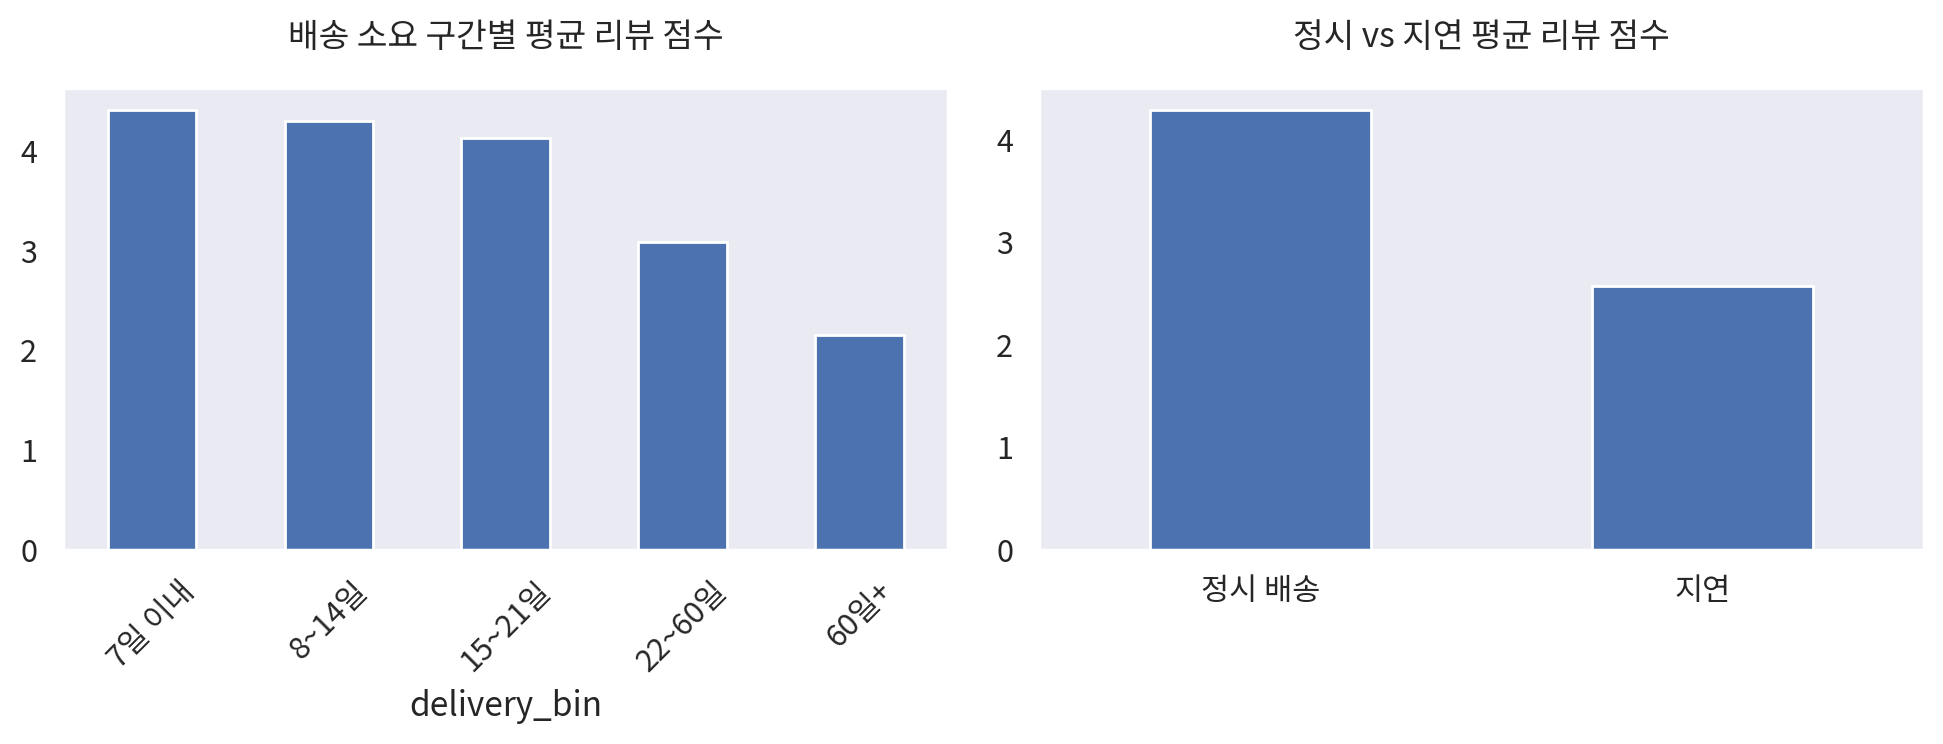

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
by_delivery["평균_리뷰점수"].plot(kind="bar", ax=axes[0])
axes[0].set_title("배송 소요 구간별 평균 리뷰 점수")
axes[0].tick_params(axis="x", rotation=45)
by_delay["평균_리뷰점수"].plot(kind="bar", ax=axes[1])
axes[1].set_title("정시 vs 지연 평균 리뷰 점수")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()